In [93]:

 # Second Assignment
# Import libraries 

import numpy as np 

from matplotlib.pylab import subplot
from sklearn.linear_model import LinearRegression 
import pandas as pd
import seaborn as sns
import math
import matplotlib.pyplot as plt

import glob
import os


df = pd.read_csv('C:\\Users\\LENOVO\\Downloads\\diabetes\\diabetes_dataset.csv')


In [94]:
# display 
df.head(9)


,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,Male,Asian,Highschool,Lower-Middle,Employed,Never,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,Female,White,Highschool,Middle,Employed,Former,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,Male,Hispanic,Highschool,Middle,Unemployed,Never,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,Female,Black,Highschool,Low,Retired,Never,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,Male,White,Graduate,Middle,Retired,Never,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1
5,46,Female,White,Highschool,Upper-Middle,Employed,Never,2,124,9.0,...,61,119,179,100,133,8.77,6.03,23.5,Pre-Diabetes,0
6,75,Female,White,Graduate,Upper-Middle,Retired,Never,0,53,9.2,...,46,161,155,101,100,10.14,5.24,36.1,Pre-Diabetes,0
7,62,Male,White,Postgraduate,Middle,Unemployed,Current,1,75,4.1,...,49,159,120,110,189,8.96,7.04,34.2,Type 2,1
8,42,Male,Black,Highschool,Lower-Middle,Employed,Current,1,114,6.7,...,33,132,98,116,172,5.70,6.90,26.7,Type 2,1


In [9]:
df.shape

(100000, 31)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 31 columns):
 #   Column                              Non-Null Count   Dtype  
---  ------                              --------------   -----  
 0   age                                 100000 non-null  int64  
 1   gender                              100000 non-null  object 
 2   ethnicity                           100000 non-null  object 
 3   education_level                     100000 non-null  object 
 4   income_level                        100000 non-null  object 
 5   employment_status                   100000 non-null  object 
 6   smoking_status                      100000 non-null  object 
 7   alcohol_consumption_per_week        100000 non-null  int64  
 8   physical_activity_minutes_per_week  100000 non-null  int64  
 9   diet_score                          100000 non-null  float64
 10  sleep_hours_per_day                 100000 non-null  float64
 11  screen_time_hours_per_day  

In [11]:
df.describe()

,age,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,cardiovascular_history,bmi,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diagnosed_diabetes
count,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50.12041,2.003670,118.911640,5.994787,6.997818,5.996468,0.219410,0.250800,0.079200,25.612653,...,185.978110,54.042790,103.000430,121.462650,111.11712,160.035050,9.061242,6.520776,30.222362,0.599980
std,15.60460,1.417779,84.409662,1.780954,1.094622,2.468406,0.413849,0.433476,0.270052,3.586705,...,32.013005,10.267374,33.390256,43.372619,13.59561,30.935472,4.954060,0.813921,9.061505,0.489904
min,18.00000,0.000000,0.000000,0.000000,3.000000,0.500000,0.000000,0.000000,0.000000,15.000000,...,100.000000,20.000000,50.000000,30.000000,60.00000,70.000000,2.000000,4.000000,2.700000,0.000000
25%,39.00000,1.000000,57.000000,4.800000,6.300000,4.300000,0.000000,0.000000,0.000000,23.200000,...,164.000000,47.000000,78.000000,91.000000,102.00000,139.000000,5.090000,5.970000,23.800000,0.000000
50%,50.00000,2.000000,100.000000,6.000000,7.000000,6.000000,0.000000,0.000000,0.000000,25.600000,...,186.000000,54.000000,102.000000,121.000000,111.00000,160.000000,8.790000,6.520000,29.000000,1.000000
75%,61.00000,3.000000,160.000000,7.200000,7.700000,7.700000,0.000000,1.000000,0.000000,28.000000,...,208.000000,61.000000,126.000000,151.000000,120.00000,181.000000,12.450000,7.070000,35.600000,1.000000
max,90.00000,10.000000,833.000000,10.000000,10.000000,16.800000,1.000000,1.000000,1.000000,39.200000,...,318.000000,98.000000,263.000000,344.000000,172.00000,287.000000,32.220000,9.800000,67.200000,1.000000


In [12]:
df.nunique()            # finding the unique values

age                                     73
gender                                   3
ethnicity                                5
education_level                          4
income_level                             5
employment_status                        4
smoking_status                           3
alcohol_consumption_per_week            11
physical_activity_minutes_per_week     620
diet_score                             101
sleep_hours_per_day                     71
screen_time_hours_per_day              156
family_history_diabetes                  2
hypertension_history                     2
cardiovascular_history                   2
bmi                                    240
waist_to_hip_ratio                      40
systolic_bp                             86
diastolic_bp                            60
heart_rate                              64
cholesterol_total                      210
hdl_cholesterol                         79
ldl_cholesterol                        190
triglycerid

In [13]:
# checking for null values 
df.isnull().sum()

age                                   0
gender                                0
ethnicity                             0
education_level                       0
income_level                          0
employment_status                     0
smoking_status                        0
alcohol_consumption_per_week          0
physical_activity_minutes_per_week    0
diet_score                            0
sleep_hours_per_day                   0
screen_time_hours_per_day             0
family_history_diabetes               0
hypertension_history                  0
cardiovascular_history                0
bmi                                   0
waist_to_hip_ratio                    0
systolic_bp                           0
diastolic_bp                          0
heart_rate                            0
cholesterol_total                     0
hdl_cholesterol                       0
ldl_cholesterol                       0
triglycerides                         0
glucose_fasting                       0


In [14]:
# our target function is diagnosis of diabetes ... value count on diabetes 
df.diagnosed_diabetes.value_counts()

1    59998
0    40002
Name: diagnosed_diabetes, dtype: int64

In [15]:
df.mode()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,52,Female,White,Highschool,Middle,Employed,Never,2,59,5.7,...,55,50,30,110,154,2.0,6.48,26.6,Type 2,1


In [16]:
# finding the standard deviation for better understanding the data 

df.std()


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_6760\198217270.py:3: FutureWarning: Dropping of nuisance columns in DataFrame reductions (with 'numeric_only=None') is deprecated; in a future version this will raise TypeError.  Select only valid columns before calling the reduction.
  df.std()


age                                   15.604600
alcohol_consumption_per_week           1.417779
physical_activity_minutes_per_week    84.409662
diet_score                             1.780954
sleep_hours_per_day                    1.094622
screen_time_hours_per_day              2.468406
family_history_diabetes                0.413849
hypertension_history                   0.433476
cardiovascular_history                 0.270052
bmi                                    3.586705
waist_to_hip_ratio                     0.046837
systolic_bp                           14.284073
diastolic_bp                           8.204250
heart_rate                             8.371954
cholesterol_total                     32.013005
hdl_cholesterol                       10.267374
ldl_cholesterol                       33.390256
triglycerides                         43.372619
glucose_fasting                       13.595610
glucose_postprandial                  30.935472
insulin_level                          4

C:\Users\LENOVO\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='diabetes_risk_score', ylabel='Density'>

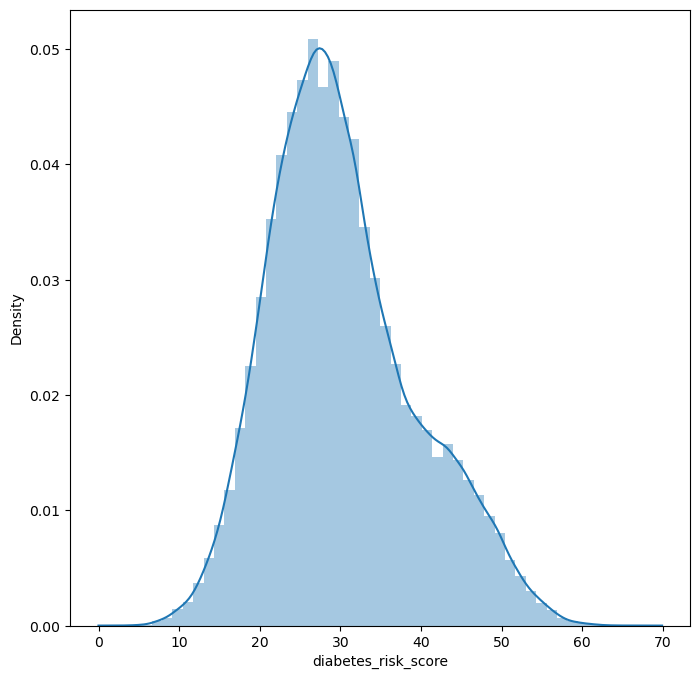

In [20]:
# look into the distribution of diabetic risk score and insulin level 

fig, axr = plt.subplots(figsize=(8,8))
sns.distplot(df.diabetes_risk_score)


C:\Users\LENOVO\anaconda3\lib\site-packages\seaborn\distributions.py:2619: FutureWarning: `distplot` is a deprecated function and will be removed in a future version. Please adapt your code to use either `displot` (a figure-level function with similar flexibility) or `histplot` (an axes-level function for histograms).
  warnings.warn(msg, FutureWarning)


<AxesSubplot:xlabel='insulin_level', ylabel='Density'>

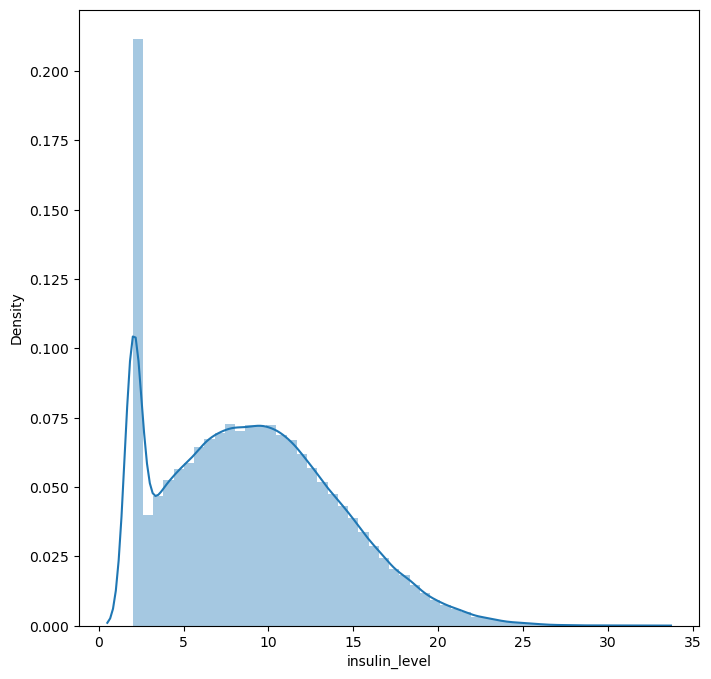

In [22]:
# looking at the distribution of insulin level 

fig, axr = plt.subplots(figsize=(8,8))
sns.distplot(df.insulin_level)

In [25]:
# finding the unique values in gender, smoking_status, employment_status, candiovascular_history
print (df['gender'].unique())
print (df['smoking_status'].unique())
print (df['employment_status'].unique())
print (df['cardiovascular_history'].unique())
print (df['income_level'].unique())

['Male' 'Female' 'Other']
['Never' 'Former' 'Current']
['Employed' 'Unemployed' 'Retired' 'Student']
[0 1]
['Lower-Middle' 'Middle' 'Low' 'Upper-Middle' 'High']


In [95]:
# now applying mapping 

df_copy22= df


In [99]:
mpp = {'Male':0,'Female':1,'Other':2}
mpp2 = {'Never':0,'Former':1,'Current':2}
mpp3 = {'Employed':0,'Unemployed':1,'Retired':2, 'Student':3}
mpp4 = {'Low':0,'Lower-Middle':1 ,'Middle':2,'Upper-Middle':3,'High':4}


#df_copy22['gender'] = df_copy22['gender'].map(mpp)
df_copy22['smoking_status'] = df_copy22['smoking_status'].map(mpp2)
#df_copy4['employment_status'] = df_copy2['smoking_status'].map(mpp3)
#df_copy4['income_level'] = df_copy2['income_level'].map(mpp4)

In [100]:
df_copy22.head()

,age,gender,ethnicity,education_level,income_level,employment_status,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,0,Asian,Highschool,Lower-Middle,Employed,0,0,215,5.7,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,1,White,Highschool,Middle,Employed,1,1,143,6.7,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,0,Hispanic,Highschool,Middle,Unemployed,0,1,57,6.4,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,1,Black,Highschool,Low,Retired,0,0,49,3.4,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,0,White,Graduate,Middle,Retired,0,1,109,7.2,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


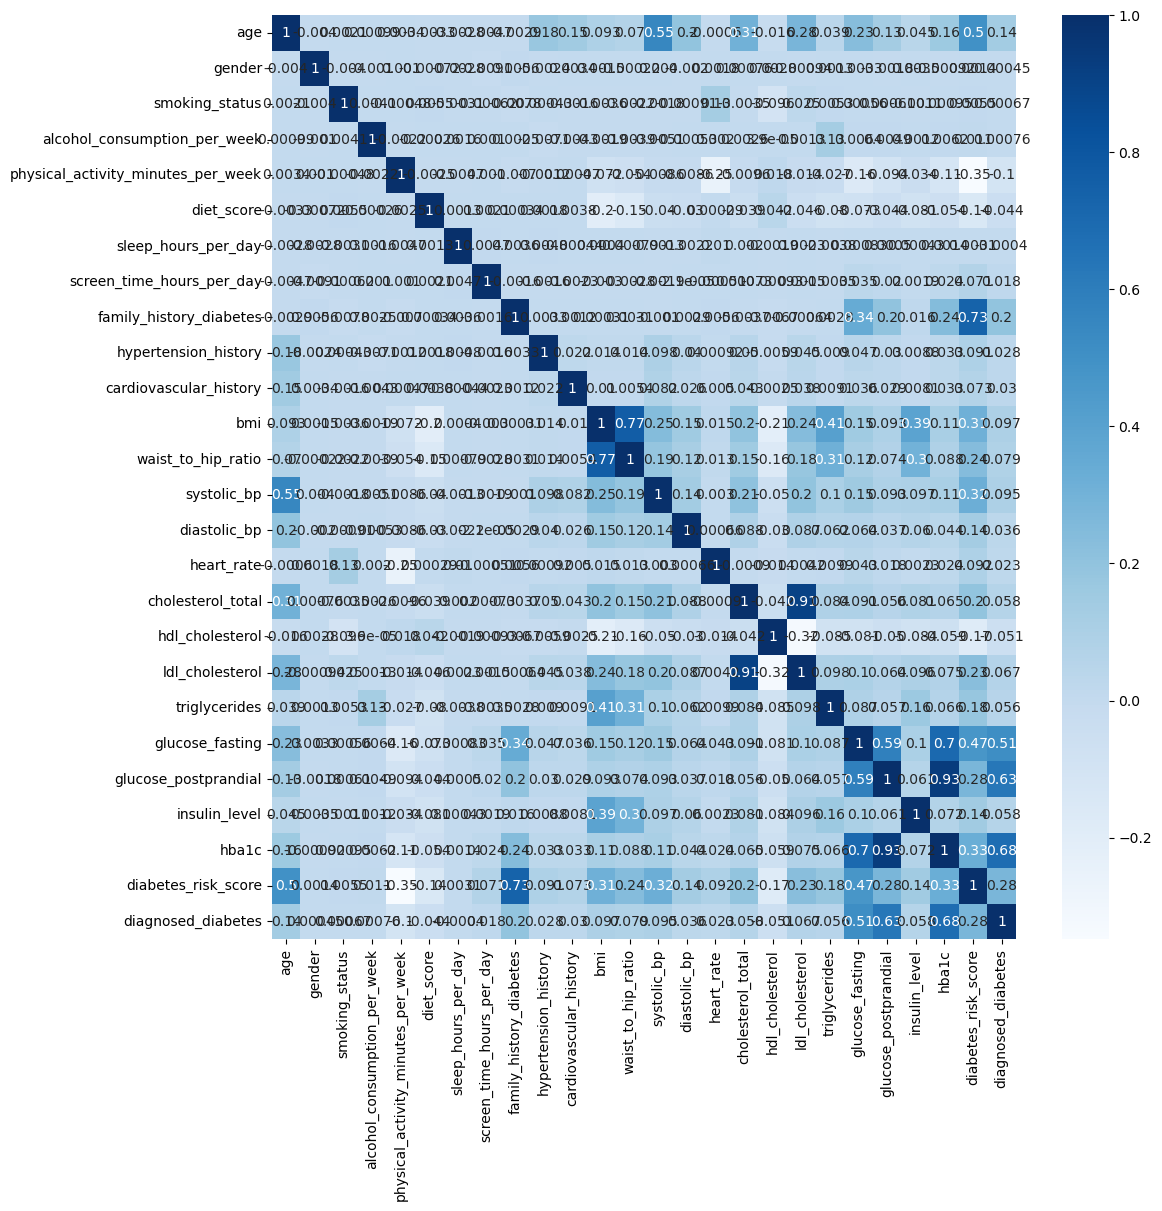

In [103]:
# corr heat map 
plt.figure(figsize=(12,12))
sns.heatmap(df_copy22.corr(), annot=True, cmap="Blues")
plt.show()

In [105]:
# looking at the histogram 
# dropping coloumns first 
df_copy22.columns

df_new = df_copy22.drop(columns=['education_level','income_level','employment_status'])


In [107]:
df_new.drop(columns='ethnicity')

,age,gender,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,0,0,0,215,5.7,7.9,7.9,0,0,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,1,1,1,143,6.7,6.5,8.7,0,0,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,0,0,1,57,6.4,10.0,8.1,1,0,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,1,0,0,49,3.4,6.6,5.2,0,0,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,0,0,1,109,7.2,7.4,5.0,0,0,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,46,0,1,1,136,8.3,6.4,4.5,0,0,...,45,150,116,113,109,14.58,5.55,26.0,Pre-Diabetes,0
99996,41,1,0,3,76,8.8,6.8,4.8,0,0,...,55,123,146,96,146,9.02,5.97,24.4,Pre-Diabetes,0
99997,57,1,1,4,121,9.9,5.0,6.1,0,0,...,50,111,184,93,132,2.57,5.21,27.6,No Diabetes,0
99998,47,1,0,3,52,5.9,6.7,0.5,0,1,...,68,91,116,106,117,9.81,5.53,26.4,Pre-Diabetes,0


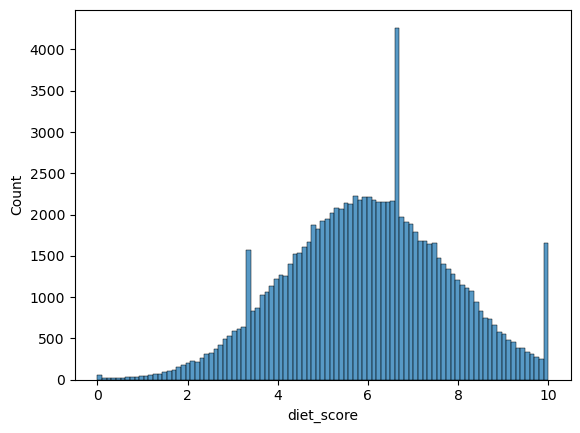

In [111]:
# plot hstogram 
sns.histplot(data = df_new , x = 'diet_score')

plt.show()


In [112]:
df_new.head()

,age,gender,ethnicity,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,0,Asian,0,0,215,5.7,7.9,7.9,0,...,41,160,145,136,236,6.36,8.18,29.6,Type 2,1
1,48,1,White,1,1,143,6.7,6.5,8.7,0,...,55,50,30,93,150,2.00,5.63,23.0,No Diabetes,0
2,60,0,Hispanic,0,1,57,6.4,10.0,8.1,1,...,66,99,36,118,195,5.07,7.51,44.7,Type 2,1
3,74,1,Black,0,0,49,3.4,6.6,5.2,0,...,50,79,140,139,253,5.28,9.03,38.2,Type 2,1
4,46,0,White,0,1,109,7.2,7.4,5.0,0,...,52,125,160,137,184,12.74,7.20,23.5,Type 2,1


In [113]:
df_new['diabetes_stage'].unique()

array(['Type 2', 'No Diabetes', 'Pre-Diabetes', 'Gestational', 'Type 1'],
      dtype=object)

In [114]:
mp = {'No Diabetes':0,'Pre-Diabetes':1,'Gestational':2,'Type 1':3,'Type 2':4}

df_new['diabetes_stage'] = df_new['diabetes_stage'].map(mp)

In [115]:
df_new.head()

,age,gender,ethnicity,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,0,Asian,0,0,215,5.7,7.9,7.9,0,...,41,160,145,136,236,6.36,8.18,29.6,4,1
1,48,1,White,1,1,143,6.7,6.5,8.7,0,...,55,50,30,93,150,2.00,5.63,23.0,0,0
2,60,0,Hispanic,0,1,57,6.4,10.0,8.1,1,...,66,99,36,118,195,5.07,7.51,44.7,4,1
3,74,1,Black,0,0,49,3.4,6.6,5.2,0,...,50,79,140,139,253,5.28,9.03,38.2,4,1
4,46,0,White,0,1,109,7.2,7.4,5.0,0,...,52,125,160,137,184,12.74,7.20,23.5,4,1


In [117]:
df_new=df_new.drop(columns='ethnicity')

In [118]:
df_new.head()

,age,gender,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,0,0,0,215,5.7,7.9,7.9,0,0,...,41,160,145,136,236,6.36,8.18,29.6,4,1
1,48,1,1,1,143,6.7,6.5,8.7,0,0,...,55,50,30,93,150,2.00,5.63,23.0,0,0
2,60,0,0,1,57,6.4,10.0,8.1,1,0,...,66,99,36,118,195,5.07,7.51,44.7,4,1
3,74,1,0,0,49,3.4,6.6,5.2,0,0,...,50,79,140,139,253,5.28,9.03,38.2,4,1
4,46,0,0,1,109,7.2,7.4,5.0,0,0,...,52,125,160,137,184,12.74,7.20,23.5,4,1


In [127]:
# now grouping pairs 
dd = df_new.groupby (['hdl_cholesterol','ldl_cholesterol','triglycerides'])['diabetes_risk_score'].mean().reset_index()

In [128]:
dd.head()

,hdl_cholesterol,ldl_cholesterol,triglycerides,diabetes_risk_score
0,20,60,142,32.8
1,20,74,137,26.7
2,20,82,105,23.0
3,20,84,141,28.4
4,20,85,77,25.4


In [132]:
# making a scatter plot 
Coles = dd ['hdl_cholesterol']+dd ['ldl_cholesterol']+dd ['triglycerides']

In [133]:
 dd['Total_col']= Coles

In [134]:
dd.head()

,hdl_cholesterol,ldl_cholesterol,triglycerides,diabetes_risk_score,Total_col
0,20,60,142,32.8,222
1,20,74,137,26.7,231
2,20,82,105,23.0,207
3,20,84,141,28.4,245
4,20,85,77,25.4,182


<AxesSubplot:xlabel='Total_col', ylabel='diabetes_risk_score'>

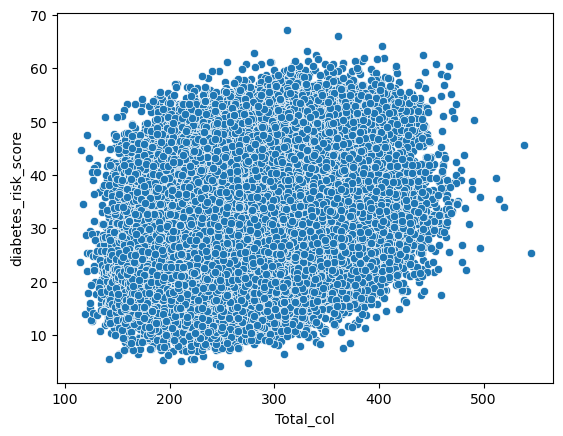

In [135]:
sns.scatterplot(x='Total_col', y='diabetes_risk_score',data = dd)

<AxesSubplot:xlabel='Total_col', ylabel='diabetes_risk_score'>

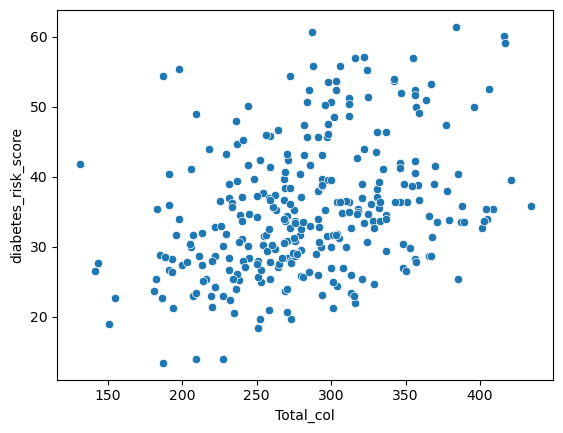

In [136]:
sns.scatterplot(x=dd.loc[0:300,'Total_col'], y=dd.loc[0:300,'diabetes_risk_score'],data = dd)

In [140]:
############ Splitting And standardization ############### 


#print (df_new.std())
df_new = df_new.drop(columns='Total_col')

In [142]:
df_new.head()
print (df_new.std())

age                                   15.604600
gender                                 0.537088
smoking_status                         0.801740
alcohol_consumption_per_week           1.417779
physical_activity_minutes_per_week    84.409662
diet_score                             1.780954
sleep_hours_per_day                    1.094622
screen_time_hours_per_day              2.468406
family_history_diabetes                0.413849
hypertension_history                   0.433476
cardiovascular_history                 0.270052
bmi                                    3.586705
waist_to_hip_ratio                     0.046837
systolic_bp                           14.284073
diastolic_bp                           8.204250
heart_rate                             8.371954
cholesterol_total                     32.013005
hdl_cholesterol                       10.267374
ldl_cholesterol                       33.390256
triglycerides                         43.372619
glucose_fasting                       13

In [143]:
df_new_copy = df_new                                           # just for backuo
X = df_new.drop(columns='diagnosed_diabetes',axis=1)
Y = df_new['diagnosed_diabetes']

In [144]:
X.head()


,age,gender,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage
0,58,0,0,0,215,5.7,7.9,7.9,0,0,...,239,41,160,145,136,236,6.36,8.18,29.6,4
1,48,1,1,1,143,6.7,6.5,8.7,0,0,...,116,55,50,30,93,150,2.00,5.63,23.0,0
2,60,0,0,1,57,6.4,10.0,8.1,1,0,...,213,66,99,36,118,195,5.07,7.51,44.7,4
3,74,1,0,0,49,3.4,6.6,5.2,0,0,...,171,50,79,140,139,253,5.28,9.03,38.2,4
4,46,0,0,1,109,7.2,7.4,5.0,0,0,...,210,52,125,160,137,184,12.74,7.20,23.5,4


In [145]:
print (Y)

0        1
1        0
2        1
3        1
4        1
        ..
99995    0
99996    0
99997    0
99998    0
99999    0
Name: diagnosed_diabetes, Length: 100000, dtype: int64


In [146]:
################## applying standard scalar ####################### 
from sklearn.preprocessing import StandardScaler


In [147]:
scaler = StandardScaler()

In [148]:
scaler.fit(X)

StandardScaler()

In [149]:
standard_data = scaler.transform(X)

In [150]:
print (standard_data)

[[ 0.50495557 -1.00993282 -0.75290358 ...  2.03856648 -0.06868231
   0.80823976]
 [-0.13588433  0.85196906  0.49438959 ... -1.09443133 -0.7970418
  -1.71480904]
 [ 0.63312355 -1.00993282 -0.75290358 ...  1.21538667  1.5977159
   0.80823976]
 ...
 [ 0.44087158  0.85196906  0.49438959 ... -1.61045449 -0.28939731
  -1.71480904]
 [-0.19996832  0.85196906 -0.75290358 ... -1.21729398 -0.42182631
  -1.08404684]
 [ 0.12045163  0.85196906 -0.75290358 ... -0.97156867 -0.25629006
  -1.08404684]]


In [154]:
X = standard_data

In [155]:
###################### Train Test Slipt Data ###############
from sklearn.model_selection import train_test_split


In [158]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y ,random_state=42, )

In [159]:
################# Applying Logistic regression ###############
from sklearn.linear_model import LogisticRegression

In [160]:
print (' Applying logistic regression')

 Applying logistic regression


In [163]:
from sklearn.metrics import classification_report, roc_auc_score, average_precision_score, confusion_matrix
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression

In [164]:
LR = LogisticRegression()             # moodel for logistic regression 

In [165]:
LR.fit(X_train,Y_train)

LogisticRegression()

In [166]:
# now predict 

y_predict = LR.predict(X_test)

In [167]:
# Evaluate the Model 
train_acc = LR.score(X_train,Y_train)
text_acc = LR.score(X_test,Y_test)

In [169]:
# printing the result 
print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy: {text_acc:.4f}")
print("-----------------------")

Train Accuracy: 0.9990
Test Accuracy: 0.9988
-----------------------


In [170]:
# classification report 
print ('The classification report is ', classification_report(Y_test,y_predict))

The classification report is                precision    recall  f1-score   support

           0       1.00      1.00      1.00      8000
           1       1.00      1.00      1.00     12000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



In [171]:
##################################### Decision Tree ##################################### 

In [173]:
print ('######## applying decision tree on the test adn training set above ##############')

######## applying decision tree on the test adn training set above ##############


In [174]:
from sklearn.tree import DecisionTreeClassifier



In [175]:
# creat the object 
DCL = DecisionTreeClassifier(criterion='entropy',max_depth=3)

In [176]:
# train the model 
DCL.fit(X_train,Y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

In [177]:
y_pred_Tree = DCL.predict(X_test)                    # predicting 

In [178]:
# Evaluate the Model 
train_acc_T = DCL.score(X_train,Y_train)
text_acc_T = DCL.score(X_test,Y_test)

In [179]:
# printing the result 
print(f"Train Accuracy: {train_acc_T:.4f}")
print(f"Test Accuracy: {text_acc_T:.4f}")
print("-----------------------")

Train Accuracy: 0.9996
Test Accuracy: 0.9997
-----------------------


In [180]:
# classification report 
print ('The classification report is ', classification_report(Y_test,y_pred_Tree))

The classification report is                precision    recall  f1-score   support

           0       1.00      1.00      1.00      8000
           1       1.00      1.00      1.00     12000

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



In [181]:
############################## KNN########################################

In [183]:
from sklearn.neighbors import KNeighborsClassifier

In [198]:
KNN = KNeighborsClassifier(n_neighbors=2)            # knn object

In [199]:
KNN.fit (X_train,Y_train)

KNeighborsClassifier(n_neighbors=2)

In [192]:
YK_predict = KNN.predict(X_test)                # predicting the KNN values

In [193]:
# Evaluate the Model 
train_acc_K = KNN.score(X_train,Y_train)
text_acc_K = KNN.score(X_test,Y_test)

In [196]:
# printing the result 
print(f"Train Accuracy: {train_acc_K:.4f}")
print(f"Test Accuracy: {text_acc_K:.4f}")
print("-----------------------")

-----------------------


n


In [200]:
###################################### Multi class **************************


In [201]:
df_new.head()

,age,gender,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,0,0,0,215,5.7,7.9,7.9,0,0,...,41,160,145,136,236,6.36,8.18,29.6,4,1
1,48,1,1,1,143,6.7,6.5,8.7,0,0,...,55,50,30,93,150,2.00,5.63,23.0,0,0
2,60,0,0,1,57,6.4,10.0,8.1,1,0,...,66,99,36,118,195,5.07,7.51,44.7,4,1
3,74,1,0,0,49,3.4,6.6,5.2,0,0,...,50,79,140,139,253,5.28,9.03,38.2,4,1
4,46,0,0,1,109,7.2,7.4,5.0,0,0,...,52,125,160,137,184,12.74,7.20,23.5,4,1


In [203]:
XM= df_new.drop(columns='diabetes_stage',axis=1)
YM = df_new['diabetes_stage']

In [204]:
# now applying standard scalaer 

sts = StandardScaler()

In [205]:
sts.fit(XM)

StandardScaler()

In [206]:
Standard_XM = sts.transform(XM)

In [207]:
XM = Standard_XM

In [208]:
################ Applying logistic regression ############################## 


In [209]:
LRM =LogisticRegression()

In [210]:
########################## Making training set ######################

In [211]:
XM_train, XM_test, YM_train, YM_test = train_test_split(XM, YM, test_size=0.2, stratify=YM ,random_state=42, )

In [212]:
LRM.fit(XM_train,YM_train)

LogisticRegression()

In [213]:
# predict using logistic regression 
YM_predict = LRM.predict(XM_test)

In [214]:
# Evaluate the Model 
train_acc = LRM.score(XM_train,YM_train)
text_acc = LRM.score(XM_test,YM_test)

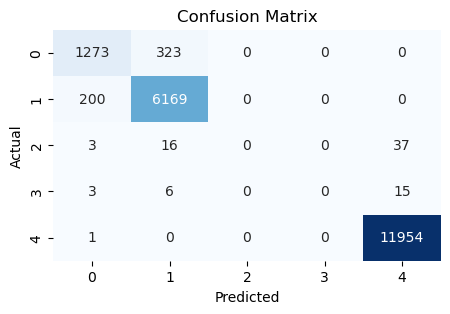

In [215]:
cm = confusion_matrix(YM_test, YM_predict)
plt.figure(figsize=(5, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [216]:
####################### decission tree ###################
DCLM = DecisionTreeClassifier(criterion='entropy',max_depth=3)

In [217]:
DCL.fit(XM_train,YM_train)

DecisionTreeClassifier(criterion='entropy', max_depth=3)

In [218]:
y_pred_Tree = DCL.predict(XM_test) 

In [219]:
# Evaluate the Model 
train_acc_T = DCL.score(XM_train,YM_train)
text_acc_T = DCL.score(XM_test,YM_test)

In [220]:
# printing the result 
print(f"Train Accuracy: {train_acc_T:.4f}")
print(f"Test Accuracy: {text_acc_T:.4f}")
print("-----------------------")

Train Accuracy: 0.9960
Test Accuracy: 0.9960
-----------------------


In [221]:
from sklearn.metrics import r2_score                 # calculation r2 values 


In [224]:
r2 = r2_score(YM_test,y_pred_Tree)
print (f'the r2 values is {r2}')

the r2 values is 0.9951261088063922


In [225]:
########################### Applying KNN ############################# 


In [226]:
KNNM = KNeighborsClassifier(n_neighbors=2)            # knn object

In [227]:
KNN.fit (XM_train,YM_train)

KNeighborsClassifier(n_neighbors=2)

In [231]:
YKM_predict = KNN.predict(XM_test)    

In [236]:
# Evaluate the Model 
train_acc_K = KNN.score(XM_train,YM_train)
text_acc_K = KNN.score(XM_test,YM_test)

In [237]:
# printing the result 
print(f"Train Accuracy: {train_acc_K:.4f}")
print(f"Test Accuracy: {text_acc_K:.4f}")
print("-----------------------")

Train Accuracy: 0.9619
Test Accuracy: 0.9074
-----------------------


In [238]:
############################ Target Diabetic risk score ##################

In [239]:
df_new.head()

,age,gender,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,...,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_risk_score,diabetes_stage,diagnosed_diabetes
0,58,0,0,0,215,5.7,7.9,7.9,0,0,...,41,160,145,136,236,6.36,8.18,29.6,4,1
1,48,1,1,1,143,6.7,6.5,8.7,0,0,...,55,50,30,93,150,2.00,5.63,23.0,0,0
2,60,0,0,1,57,6.4,10.0,8.1,1,0,...,66,99,36,118,195,5.07,7.51,44.7,4,1
3,74,1,0,0,49,3.4,6.6,5.2,0,0,...,50,79,140,139,253,5.28,9.03,38.2,4,1
4,46,0,0,1,109,7.2,7.4,5.0,0,0,...,52,125,160,137,184,12.74,7.20,23.5,4,1


In [240]:
XX = df_new.drop(columns='diabetes_risk_score',axis=1)
YY = df_new['diabetes_risk_score']

In [241]:
XX.head()

,age,gender,smoking_status,alcohol_consumption_per_week,physical_activity_minutes_per_week,diet_score,sleep_hours_per_day,screen_time_hours_per_day,family_history_diabetes,hypertension_history,...,cholesterol_total,hdl_cholesterol,ldl_cholesterol,triglycerides,glucose_fasting,glucose_postprandial,insulin_level,hba1c,diabetes_stage,diagnosed_diabetes
0,58,0,0,0,215,5.7,7.9,7.9,0,0,...,239,41,160,145,136,236,6.36,8.18,4,1
1,48,1,1,1,143,6.7,6.5,8.7,0,0,...,116,55,50,30,93,150,2.00,5.63,0,0
2,60,0,0,1,57,6.4,10.0,8.1,1,0,...,213,66,99,36,118,195,5.07,7.51,4,1
3,74,1,0,0,49,3.4,6.6,5.2,0,0,...,171,50,79,140,139,253,5.28,9.03,4,1
4,46,0,0,1,109,7.2,7.4,5.0,0,0,...,210,52,125,160,137,184,12.74,7.20,4,1


In [248]:
############### Splitting the Data set #####################
print (YY)

0        29.6
1        23.0
2        44.7
3        38.2
4        23.5
         ... 
99995    26.0
99996    24.4
99997    27.6
99998    26.4
99999    27.9
Name: diabetes_risk_score, Length: 100000, dtype: float64


In [250]:
XX.shape

(100000, 26)

In [254]:
sca = StandardScaler()

In [255]:
sca.fit(XX)

StandardScaler()

In [256]:
SCAX = sca.transform(XX)

In [257]:
XX = SCAX

In [259]:
print (XX)

[[ 0.50495557 -1.00993282 -0.75290358 ...  2.03856648  0.80823976
   0.8165306 ]
 [-0.13588433  0.85196906  0.49438959 ... -1.09443133 -1.71480904
  -1.22469384]
 [ 0.63312355 -1.00993282 -0.75290358 ...  1.21538667  0.80823976
   0.8165306 ]
 ...
 [ 0.44087158  0.85196906  0.49438959 ... -1.61045449 -1.71480904
  -1.22469384]
 [-0.19996832  0.85196906 -0.75290358 ... -1.21729398 -1.08404684
  -1.22469384]
 [ 0.12045163  0.85196906 -0.75290358 ... -0.97156867 -1.08404684
  -1.22469384]]


In [263]:
XM_train, XM_test, YM_train, YM_test = train_test_split(XX, YY, test_size=0.2, random_state=42, )

In [264]:
###################### Applying linear regression ###################

In [265]:
LRX = LinearRegression()

In [266]:
LRX.fit(XM_train,YM_train)

LinearRegression()

In [267]:
YY_pred = LRX.predict(XM_test)

In [268]:
r2 = r2_score(YM_test,YY_pred )                           # predicting r2 values for linear regression 
print (f'the r2 values is {r2}')

the r2 values is 0.9932821218003393


In [269]:
from sklearn.metrics import mean_squared_error

In [271]:
# calculating the mean square error 
mse = mean_squared_error(YM_test, YY_pred)
print (f'The mean square error is {mse} ')


The mean square error is 0.5544085287649038 


In [272]:
######################### applying decision tree regressor ############################

In [273]:
from sklearn.tree import DecisionTreeRegressor

In [274]:
model = DecisionTreeRegressor(max_depth=3 , random_state=0)

In [275]:
model.fit(XM_train,YM_train)

DecisionTreeRegressor(max_depth=3, random_state=0)

In [276]:
y_pred_tree = model.predict(XM_test)

In [277]:
mset = mean_squared_error(YM_test,y_pred_tree)
print (f'The mean square error is {mset} ')

The mean square error is 18.0181178213405 


In [278]:
############################# Applying Hyper Parameters ##########################

In [279]:
##################### i select logistic regression and apply hyper parameter tuning on it ###########

In [280]:
####################### i select C parameter for tunning ##################

In [281]:
from sklearn.model_selection import GridSearchCV                          # importing grid searching 

In [282]:
param_gris ={'C':[ 0.001,0.01,0.1,1,10]}                               # defining the c parameter ranges 

In [284]:
# initiate the gris search 

grid_search = GridSearchCV(LogisticRegression(max_iter=1000), param_gris , cv=5)

In [285]:
# X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, stratify=Y ,random_state=42, )
# Select the targedof diagnosed disbetic
# fit the grid with data 

grid_search.fit(X_train,Y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(max_iter=1000),
             param_grid={'C': [0.001, 0.01, 0.1, 1, 10]})

In [286]:
# printing the best parameters 

print (' The Best parameter of C :', grid_search.best_params_)

 The Best parameter of C : {'C': 1}


In [287]:
#################################### testing for different Parameter ####################

In [ ]:
param_grid = {
    'C': [0.001, 0.01, 0.1, 1, 10, 100],
    'penalty': ['l1', 'l2'],
    'solver': ['liblinear', 'saga'] # Compatible solvers for L1/L2
}

In [ ]:
# 3. Use Grid Search with Cross-Validation
grid_search2 = GridSearchCV(LogisticRegression(max_iter=1000), param_grid , cv=5)


In [ ]:
grid_search2.fit(X_train,Y_train)

In [ ]:

print (' The Best parameter of C :', grid_search.best_params_)

In [ ]:
########################### clarity of the issue ########################
###################### the above code does not run and gives no error
############ the system hangs ##################

In [ ]:
######################### Tring random search methos 

In [295]:
print (' running random search')

 running random search
